In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.float_format', '{:.6f}'.format)
from astropy.io import fits
import pandas as pd
import lightkurve as lk
import os
import csv
import scipy
from astropy.timeseries import LombScargle
import glob


In [11]:
def smooth_median(x, y, window_size):
    binsize = np.median(np.diff(x))
    yf = scipy.ndimage.median_filter(y, int(np.ceil(window_size/binsize)))
    return yf

In [12]:
def smooth(x, y, windowSize, windowType, samplingInterval=None):
    '''
    Wrapping a sliding-average smooth function.

    Input:
    x: the independent variable of the time series.
    y: the dependent variable of the time series.
    windowSize: the period/width of the sliding window.
    windowType: flat/hanning/hamming/bartlett/blackman/gaussian
    samplingInterval: the time between adjacent sampling points.

    Output:
    yf: the smoothed time series with the exact same points as x.

    '''

    if len(x) != len(y): 
        raise ValueError("x and y must have equal size.")
        
    if samplingInterval is None: 
        samplingInterval = np.median(x[1:-1] - x[0:-2])
        
    xp = np.arange(np.min(x),np.max(x),samplingInterval)
    yp = np.interp(xp, x, y)
    
    window_len = int(windowSize/samplingInterval)
    if window_len % 2 == 0:
        window_len = window_len + 1
    
        
    ys = smooth_series(yp, window_len, window = windowType)
    yf = np.interp(x, xp, ys)

    return yf

def smooth_series(x, window_len = 11, window = "hanning"):
    # stole from https://scipy.github.io/old-wiki/pages/Cookbook/SignalSmooth
    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")
    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")
    if window_len < 3:
        return x
    if not window in ["flat", "hanning", "hamming", "bartlett", "blackman", "gaussian"]:
        raise ValueError("Window is on of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")

    s = x #np.r_[x[window_len-1:0:-1],x,x[-1:-window_len:-1]]
    if window == "flat":
        w = np.ones(window_len,"d")
    elif window == "gaussian":
        w = gaussian(np.arange(-window_len*3, window_len*3,1), 
                    0, window_len, 1./(np.sqrt(2*np.pi)*window_len))
    else:
        w = eval("np."+window+"(window_len)") 
    
    y = np.convolve(w/w.sum(),s,mode="same")
    return y

def fourier(x, y, dy=None, oversampling=1, freqMin=None, freqMax=None, freq=None, return_val="power"):
    """
    Calculate the power spectrum density for a discrete time series.
    https://en.wikipedia.org/wiki/Spectral_density


    Input:
    x: array-like[N,]
        The time array.

    y: array-like[N,]
        The flux array.


    Optional input:
    dy: float, or array-like[N,]
        errors on y
    
    oversampling: float, default: 1
        The oversampling factor to control the frequency grid.
        The larger the number, the denser the grid.

    freqMin: float, default: frequency resolution

    freqMax: float, default: nyquist frequency


    Output:
    freq: np.array
        The frequency, in unit of [x]^-1.

    psd: np.array
        The power spectrum density, in unit of [y]^2/[x].
        https://en.wikipedia.org/wiki/Spectral_density


    Examples:
    >>> ts = np.load("flux.npy")
    >>> t = ts["time_d"]   # the time in day
    >>> f = ts["flux_mf"]   # the relative flux fluctuated around 1
    >>> f = (f-1)*1e6   # units, from 1 to parts per million (ppm)

    >>> freq, psd = fourier(t, f, return_val="psd_new")
    >>> freq = freq/(24*3600)*1e6   # c/d to muHz
    >>> psd = psd*(24*3600)*1e-6   # ppm^2/(c/d) to ppm^2/muHz

    """

    if not (return_val in ["psd_old", "periodogram", "power", "amplitude", "psd", "window"]):
        raise ValueError("return_val should be one of ['psd_old', 'periodogram', 'power', 'amplitude', 'psd_new', 'window'] ")

    Nx = len(x)
    dx = np.median(x[1:]-x[:-1]) 
    fs = 1.0/dx
    Tobs = dx*len(x)
    fnyq = 0.5*fs
    dfreq = fs/Nx
    #print(dfreq)

    if freqMin is None: freqMin = dfreq
    if freqMax is None: freqMax = fnyq

    if freq is None: freq = np.arange(freqMin, freqMax, dfreq/oversampling)
    #print(freq)
    if return_val == "psd_old":
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')*dx*4.
    if return_val == "periodogram":
        # text book def of periodogram
        # don't think seismologists use this
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')
    if return_val == "power":
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A^2 in the power spectrum.
        p = LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.
        #print(p)
    if return_val == "amplitude":
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A in the amp spectrum.
        p = np.sqrt(LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.)
    if return_val == "psd": 
        # normalized according to kb95
        # a sine wave with amplitude A will have peak height of A^2*Tobs in the power density spectrum.
        # should be equivalent to psd_old
        nu = 0.5*(freqMin+freqMax)
        freq_window = np.arange(freqMin, freqMax, dfreq/10)
        power_window = LombScargle(x, np.sin(2*np.pi*nu*x)).power(freq_window, normalization="psd")/Nx*4.
        Tobs = 1.0/np.sum(np.median(freq_window[1:]-freq_window[:-1])*power_window)
        p = (LombScargle(x, y, dy=dy).power(freq, normalization='psd')/Nx*4.)*Tobs
    if return_val == "window":
        # give spectral window
        nu = 0.5*(freqMin+freqMax)
        freq_window = np.arange(freqMin, freqMax, dfreq/10)
        power_window = LombScargle(x, np.sin(2*np.pi*nu*x)).power(freq_window, normalization="psd")/Nx*4.
        freq, p = freq_window-nu, power_window

    return freq, p


def background_estimate(ν1, ν2,freq,psd): #background estimate
    P1 = np.mean(psd[(freq >(ν1-100)) & (freq < (ν1+100))]) #these four lines estimate the alpha and beta
    P2 = np.mean(psd[(freq > (ν2-100)) & (freq < (ν2+100))])
    β =  np.log(P1/P2)/np.log(ν1/ν2)
    α = P1/ν1**β 

    #psd = psd/(α*freq**β)
    #psds = scipy.ndimage.gaussian_filter(psd, Dnu*0.01/np.median(np.diff(freq)))
    
    psd_background=(α * freq**β)
    if freq.min() > (ν1 + 100) or freq.max() < (ν2 - 100):
        raise ValueError(f"PSD for KIC doesn't span full 100–10,000 µHz")
    return psd_background #plotting the alpha and beta
 
    

In [13]:
#background fitting


def fit_background(freq, power, power_smooth, numax, fnyq, NHarvey=1, if_return_oscillation=False):
    
    def spectral_response(x, fnyq):
        sincfunctionarg = (np.pi/2.0)*x/fnyq
        response = (np.sin(sincfunctionarg)/sincfunctionarg)**2.0
        return response

    def standard_background_model(x, params, fnyq, NHarvey=1, if_return_oscillation=True):
        flatNoiseLevel, heightOsc, numax, widthOsc = params[0:4]
        power_model = np.zeros(len(x))
        zeta = 2.0 * 2.0**0.5 / np.pi
        for iHarvey in range(NHarvey):
            ampHarvey, freqHarvey, powerHarvey = params[iHarvey*3+4:iHarvey*3+7]
            power_model += zeta * ampHarvey**2.0 / (freqHarvey * (1 + (x/freqHarvey)**powerHarvey))
        if if_return_oscillation:
            power_model += heightOsc * np.exp(-1.0*(numax - x)**2 / (2.0 * widthOsc**2.0))
        power_model *= spectral_response(x, fnyq)
        power_model += flatNoiseLevel
        return power_model

    def guess_background_params(freq, power_smooth, numax, NHarvey=1):
        zeta = 2*2**0.5/np.pi
        flatNoiseLevel = np.median(power_smooth[int(len(freq)*0.9):])
        heightOsc = power_smooth[np.argmin(np.abs(freq - numax))]
        widthOsc = 3.0 * (0.263 * numax**0.772)
        freqHarvey_solar = np.array([2440.5672465, 735.4653975, 24.298031575])
        numax_solar = 3050
        freqHarvey = numax / numax_solar * freqHarvey_solar
        powerHarvey = np.ones(3) * 4.
        ampHarvey = np.zeros(3)
        for iHarvey in range(3):
            ampHarvey[iHarvey] = (power_smooth[np.argmin(np.abs(freq - freqHarvey[iHarvey]))] * 2 / zeta * freqHarvey[iHarvey])**0.5

        paramsInit = [flatNoiseLevel, heightOsc, numax, widthOsc,
                      ampHarvey[0], freqHarvey[0], powerHarvey[0]]
        paramsBounds = [
            [flatNoiseLevel*0.1, flatNoiseLevel*1.1],
            [heightOsc*0.2, heightOsc*5.0],
            [numax*0.5, numax*2.0],
            [widthOsc*0.1, widthOsc*4.0],
            [ampHarvey[0]*0.3, ampHarvey[0]*3.0],
            [freqHarvey[0]*0.2, freqHarvey[0]*5.0],
            [2.0, 8.0]
        ]
        return paramsInit[:4+NHarvey*3], paramsBounds[:4+NHarvey*3]

    # Get initial guesses
    paramsInit, paramsBounds = guess_background_params(freq, power_smooth, numax, NHarvey)

    def func(params):
        model = standard_background_model(freq, params, fnyq, NHarvey, if_return_oscillation=True)
        return np.sum(np.log(model) + power / model)

    # Optimize
    minimizer_kwargs = {"bounds": paramsBounds}
    res = scipy.optimize.minimize(func, paramsInit, **minimizer_kwargs)
    params_best = res.x
    background = standard_background_model(freq, params_best, fnyq, NHarvey, if_return_oscillation)
    return params_best, background


In [ ]:
#Lund et al 2017 LEGACY sample
stars=pd.read_excel('lund+17-legacy-table1 (1).xlsx')
stars.columns

Index(['KIC', 'Gamma', 'e_Gamma', 'Amax', 'e_Amax', 'N2', 'Nf', 'Name',
       'Kpmag', 'numax', 'Dnu', 'N', 'Cat', 'BkQ', 'Teff', 'e_Teff', '[Fe/H]',
       'e_[Fe/H]', 'logg', 'e_logg', 'E_logg', 'Vlos', 'e_Vlos', 'vsini',
       'e_vsini', '_RA', '_DE', 'V1', 'e_V1', 'E_V1', 'V2', 'e_V2', 'E_V2',
       'V3', 'e_V3', 'E_V3', 'Vtot', 'e_Vtot', 'E_Vtot', 'KIC.1',
       'Gamma_nu_max', 'e_Gamma_nu_max', 'A_max', 'e_A_max', 'E_A_max',
       'A_max_smooth_c3.04', 'A_max_smooth_c_Vtot2', 'alpha', 'e_alpha',
       'E_alpha', 'Gamma_alpha', 'e_Gamma_alpha', 'DeltaGamma_dip',
       'e_DeltaGamma_dip', 'E_DeltaGamma_dip', 'W_dip', 'e_W_dip', 'E_W_dip',
       'nu_dip', 'e_nu_dip', 'E_nu_dip', 'FWHM_dip', 'e_FWHM_dip'],
      dtype='object')

In [ ]:
def Motherload_SBR(star):
    kic_id=star['KIC']
    print(f"Processing KIC {kic_id}")
    try:
            
        search_result=lk.search_lightcurve(f"KIC {kic_id}",author='Kepler',
                                          exptime=60)
        star_download=search_result.download_all(cache=False)
        star_graph=star_download.stitch()
        mask_quality=star_graph.quality==0
        time_filtered=np.array(star_graph.time[mask_quality].value)
        norm_flux_filtered=np.array(star_graph.flux[mask_quality].value)

        mask_finite=np.isfinite(time_filtered) & np.isfinite(norm_flux_filtered)
        time_filtered=time_filtered[mask_finite]
        norm_flux_filtered=norm_flux_filtered[mask_finite]

        sorted_indices=np.argsort(time_filtered)
        star_time=time_filtered[sorted_indices]
        star_flux=norm_flux_filtered[sorted_indices]


        power_spectrum=fourier(star_time,star_flux)
        plt.figure()
        low_pass=smooth_median(star_time,star_flux,1/24)
        plt.plot(star_time,star_flux,'.',label=f'{kic_id}')
        plt.plot(star_time,low_pass,'.',label=f'low pass of {kic_id}',alpha=.1)
        plt.title(f'lightcurve of {kic_id} with low pass filter after artifact removal')
        plt.savefig(f'all_SBR_figures/time_series_figure_{kic_id}.jpeg')
        high_pass=star_flux-low_pass

        high_pass_pow=fourier(star_time,high_pass,dy=None,oversampling=1,
                             freqMin=None,freqMax=None,freq=None,return_val='power')

        high_pass_pow=list(high_pass_pow)
        high_pass_pow[0]=high_pass_pow[0]*11.575
        #smooth_star=smooth(high_pass_pow[0],high_pass_pow[1],3,'bartlett',samplingInterval=None)

        numax_star = star['numax']
        Dnu_star = star['Dnu']
        psd_bg=background_estimate(numax_star*.5, numax_star*2,high_pass_pow[0],high_pass_pow[1])


        fnyq_star = 1/(2*60)*1e6  # in units of microHz
        freq_star = high_pass_pow[0]
        power_star = high_pass_pow[1]
        #powers_star = smooth_star

        psds = scipy.ndimage.gaussian_filter(power_star, Dnu_star*0.01/np.median(np.diff(high_pass_pow[0])))
        print(Dnu_star*0.01/np.median(np.diff(high_pass_pow[0])))
        
        psds_arr=np.array([freq_star,psds]).T
        np.save(f'all_psds_data/psds_{kic_id}',psds_arr)


        #params, background_fit = fit_background(freq_star, power_star,
                                    #powers_star, numax_star, fnyq_star)



        plt.figure()
        plt.plot(high_pass_pow[0],high_pass_pow[1],label='Observed Power Spectrum',alpha=.5)
        plt.plot(high_pass_pow[0],psd_bg,label='background estimate',color='orange',zorder=100)
        plt.plot(high_pass_pow[0],psds,label='smoothed power spectrum',color='green')
        #plt.plot(high_pass_pow[0], background_fit, label="Fitted Background Model", linewidth=2)
        #plt.plot(freq_plot,psd_plot,label='Smoothed Power Spectrum',color='green')


        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('\u03bcHz')
        plt.ylabel('Power')
        plt.title(f'{kic_id} Power Spectrum')
        plt.legend()
        plt.xlim(10**2.5,10**4)
        plt.savefig(f'all_SBR_figures/power_figure_{kic_id}.jpeg')
        plt.show()
        plt.figure()
        SBR=high_pass_pow[1]/psd_bg
        plt.figure(figsize=(9,5))
        plt.plot(high_pass_pow[0], SBR,color='green')
        plt.title(f'SBR of {kic_id}')
        plt.xlabel('\u03bcHz')
        plt.ylabel('High Pass Power Flux \ Background Fit')
        #plt.ylim(0,30) #zoom in if you want to see the SBR better, but it cuts off the peaks
        #plt.xlim(1000,2000)
        plt.savefig(f'all_SBR_figures/SBR_figure_{kic_id}.jpeg')
        plt.show()
        arr=np.array([high_pass_pow[0],SBR]).T #make array with two rows, the .T transposes the array to be 2 columns instead of 2 rows 
        np.save(f'all_SBR_data/SBR_{kic_id}',arr)
        
        
    except Exception as e:
        print(f"Lightkurve failed for KIC {kic_id}: {e}")
        # Attempt to delete corrupt cache files
        pattern = f"*{kic_id}*"
        corrupted_files = glob.glob(os.path.expanduser(f"~/.lightkurve/cache/**/*{kic_id}*.fits"), recursive=True)
        for file in corrupted_files:
            try:
                os.remove(file)
                print(f"Deleted corrupt file: {file}")
            except Exception as delete_err:
                print(f"Could not delete {file}: {delete_err}")



Processing KIC 1435467
58.05809709744467


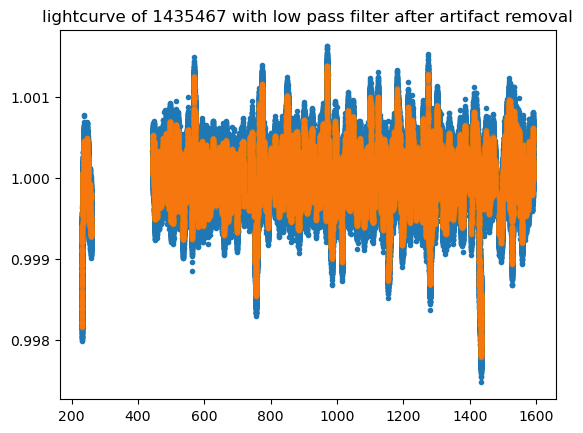

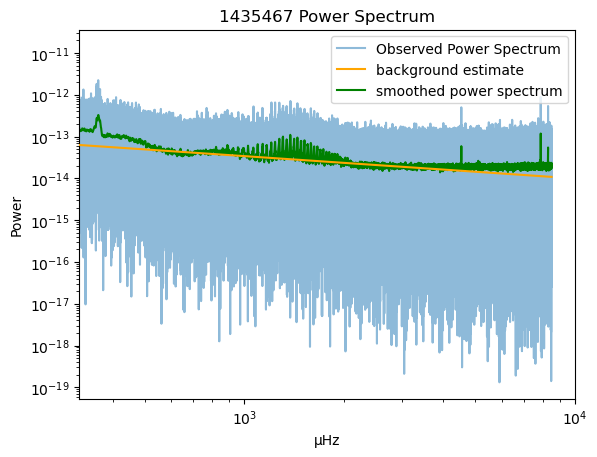

<Figure size 640x480 with 0 Axes>

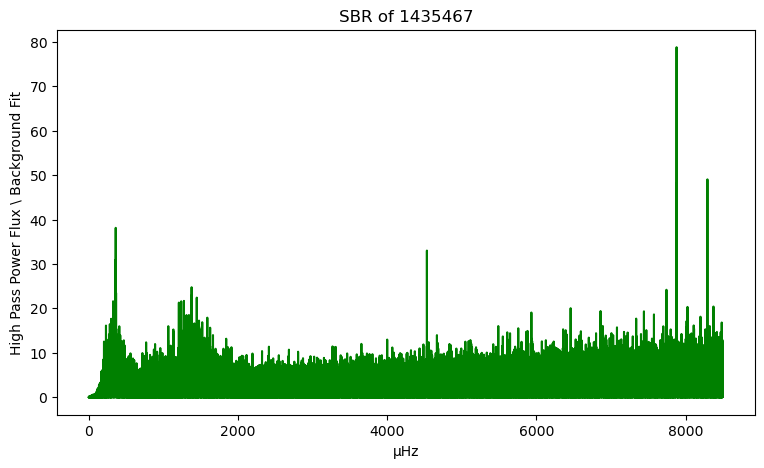

Processing KIC 2837475
60.556720655338324


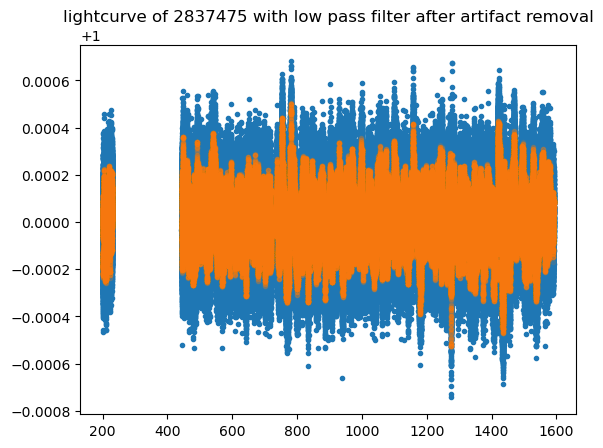

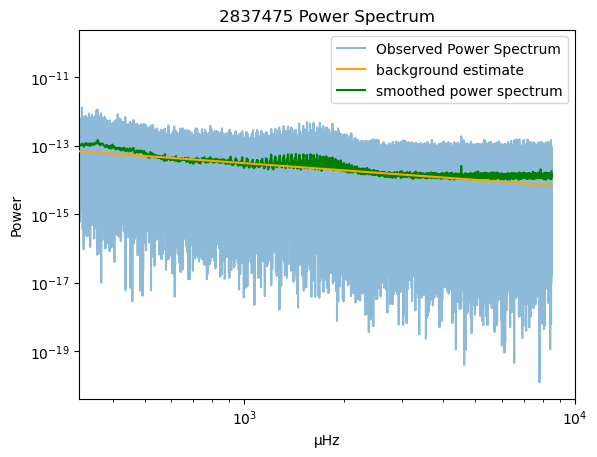

<Figure size 640x480 with 0 Axes>

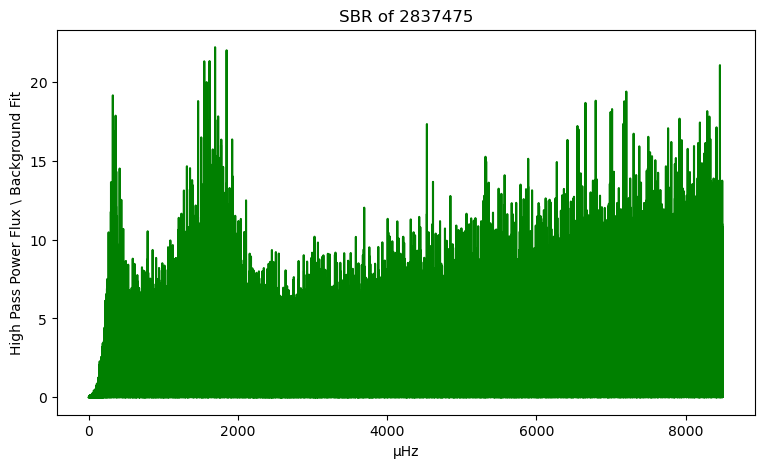

In [ ]:
for istar, star in stars.iterrows(): 
    Motherload_SBR(star)  